<a href="https://colab.research.google.com/github/NasserYQ/Saudi-Female-Owned-enterprises-2030/blob/main/Female_Owned_Enterprises_2030.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🇸🇦 Female-Owned Enterprises in Saudi Arabia — Forecast to 2030

**Project Goal:** Analyze quarterly data of female-owned enterprises across all Saudi regions and build a machine learning model to predict the total count by 2030.

---

## 📋 Table of Contents
1. Libraries & Setup
2. Load & Merge Data
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Visualization
6. ML Model — Forecast to 2030
7. Results Summary

---

## 📦 Dataset Info
| File | Quarter | Rows |
|---|---|---|
| Female_Owned_Enterprises_First_Quarter.csv | Q1 2025 | 6,801 |
| Female_Owned_Enterprises_Second_Quarter.csv | Q2 2025 | 6,801 |
| Female_Owned_Enterprises_Third_Quarter.csv | Q3 2025 | 6,801 |
| Female_Owned_Enterprises_Fourth_Quarter.csv | Q4 2025 | 3,311 |

> ⚠️ **Q4 note:** Q4 has roughly half the rows of other quarters but reports the highest enterprise count. This suggests Q4 rows use broader aggregation categories — the totals are valid but row counts are not directly comparable across quarters.

---
## 1 — Setup

In [1]:
# ── Standard libraries ──────────────────────────────────────────
import pandas as pd                          # Data manipulation
import numpy as np                           # Numerical operations

# ── Visualization ───────────────────────────────────────────────
import matplotlib.pyplot as plt              # Core plotting
import matplotlib.ticker as mticker          # Axis formatting
import seaborn as sns                        # Statistical charts

# ── Machine Learning ────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats                      # Prediction interval critical values

# ── Settings ────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Color palette for charts
PALETTE = ['#C8102E', '#006C35', '#1A5276', '#F39C12', '#8E44AD']

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


---
## 2 — Data

Four quarterly CSV files from the General Authority for Statistics (GASTAT), covering all registered female-owned enterprises in Saudi Arabia across **13 regions**, **89 economic activities**, and **4 size categories** throughout 2025.

> Q4 has roughly half the row count of other quarters due to broader aggregation in the source file — the enterprise totals are valid and consistent with the upward trend.

---
## Step 2 — Load & Merge Data

### 🔧 Pandas Methods Used Here

| Method | What it does |
|---|---|
| `pd.read_csv(path)` | Reads a CSV file and returns a DataFrame |
| `df.columns.str.strip()` | Removes leading/trailing whitespace from column names |
| `pd.concat([df1, df2, ...])` | Stacks multiple DataFrames vertically into one |
| `df.shape` | Returns `(rows, columns)` — the size of the DataFrame |
| `df.head(n)` | Shows the first `n` rows |

> ⚠️ **Colab tip:** Upload all 4 CSV files first via the 📁 sidebar → Upload, then run this cell.

---
## 3 — Cleaning

The raw files embed 10,645 rows of disclaimer text as trailing metadata, which appear as fully-NaN data rows. These are dropped, leaving **13,069 clean records**. Arabic column names are mapped to English, and numeric columns are cast from float to int. A `time_index` feature (`year × 4 + quarter`) is engineered to give the model a single monotonically increasing numeric input.

---
## Step 3 — Data Cleaning

Raw data is almost never ready to use. We need to:
1. **Select** only the useful columns
2. **Rename** columns to English (easier to work with)
3. **Drop** missing values (`NaN`)
4. **Fix** data types (numbers stored as text, etc.)
5. **Engineer** a new feature: `time_index`

### 🔧 Pandas Methods Used Here

| Method | What it does |
|---|---|
| `df[list_of_cols]` | Selects specific columns only |
| `df.copy()` | Creates an independent copy (avoids modifying the original) |
| `df.rename(columns={...})` | Renames columns using a dictionary |
| `df.isnull().sum()` | Counts missing values per column |
| `df.dropna()` | Removes rows that have any missing value |
| `df['col'].astype(type)` | Converts a column to a specific data type |
| `df.info()` | Shows column names, types, and non-null counts |
| `df.describe()` | Summary statistics (mean, std, min, max, etc.) |

In [2]:
# ── 3a. Select only the 6 useful columns ────────────────────────
COLUMN_MAP = {
    'السنة'                                 : 'year',
    'الربع'                                 : 'quarter',
    'المنطقة'                               : 'region',
    'النشاط الاقتصادي - المستوى الثاني'     : 'activity',
    'حجم المنشأة'                           : 'size',
    'عدد المنشآت المملوكة للمرأة'           : 'count',
}

# df[list] → selects specific columns
# .copy()  → makes an independent copy so we don't modify df_raw
df = df_raw[list(COLUMN_MAP.keys())].copy()

# ── 3b. Rename Arabic columns to English ────────────────────────
# .rename(columns=dict) → renames columns using old:new mapping
df.rename(columns=COLUMN_MAP, inplace=True)  # inplace=True → modifies df directly

print('── Missing values BEFORE cleaning ──')
print(df.isnull().sum())   # .isnull() → True where value is NaN
                            # .sum()    → counts Trues per column

# ── 3c. Drop rows with missing values ───────────────────────────
# .dropna() → removes any row that has at least one NaN
df.dropna(inplace=True)

print(f'\n── Missing values AFTER cleaning ──')
print(df.isnull().sum())
print(f'\n✅ Clean rows: {df.shape[0]:,}')

NameError: name 'df_raw' is not defined

---
## 4 — Exploratory Analysis

Key dimensions explored: quarterly growth trajectory, regional concentration, enterprise size distribution, and dominant economic sectors.

---
## Step 4 — Exploratory Data Analysis (EDA)

Before modeling, we explore the data to understand:
- How the total count changes each quarter
- Which regions have the most female-owned enterprises
- What sizes and sectors dominate

### 🔧 Pandas Methods Used Here

| Method | What it does |
|---|---|
| `df.groupby(col)` | Groups rows by a column's value |
| `.sum()` / `.mean()` / `.count()` | Aggregation: total / average / count per group |
| `.reset_index()` | Converts groupby result back to a normal DataFrame |
| `.sort_values(ascending=...)` | Sorts rows by a column |
| `df['col'].nunique()` | Counts distinct (unique) values in a column |
| `df['col'].unique()` | Lists all distinct values |
| `df['col'].value_counts()` | Counts how many times each value appears |
| `df.corr()` | Correlation matrix between all numeric columns |

In [ ]:
# ── 4a. Total enterprises per quarter ───────────────────────────
# .groupby(['year','quarter']) → group rows by year AND quarter
# ['count'].sum()              → sum the count column within each group
# .reset_index()               → turn result back into a flat DataFrame
quarterly = (
    df.groupby(['year', 'quarter'])['count']
      .sum()
      .reset_index()
      .sort_values(['year', 'quarter'])  # .sort_values() → sort rows
)

# Create a readable label and a numeric time_index for ML
quarterly['label']      = quarterly['year'].astype(str) + '-Q' + quarterly['quarter'].astype(str)
quarterly['time_index'] = quarterly['year'] * 4 + quarterly['quarter']

print('── Total enterprises per quarter ──')
print(quarterly[['label', 'count']].to_string(index=False))

── Total enterprises per quarter ──
  label  count
2025-Q1 682598
2025-Q2 709779
2025-Q3 729269
2025-Q4 774123


In [ ]:
# ── 4c. By enterprise size ────────────────────────────────────────
size_dist = (
    df.groupby('size')['count']
      .sum()
      .sort_values(ascending=False)
)
print('── Distribution by enterprise size ──')
print(size_dist.to_string())

# ── 4d. Top 8 economic activities ────────────────────────────────
top_activities = (
    df.groupby('activity')['count']
      .sum()
      .sort_values(ascending=False)
      .head(8)  # .head(n) → top n rows
)
print('\n── Top 8 economic activities ──')
print(top_activities.to_string())

# ── Data quality note ─────────────────────────────────────────────
unknown_count = df[df['activity'] == 'غير معرف']['count'].sum()
total_count   = df['count'].sum()
print(f'\n⚠️  "غير معرف" (Unknown) activity: {unknown_count:,} enterprises '
      f'({unknown_count / total_count * 100:.1f}% of total).')
print('   Sector-level findings should be interpreted with this in mind.')

In [ ]:
# ── 4e. Correlation (on quarterly aggregated data) ───────────────
# Using quarterly totals — the raw df has year=2025 for every row
# (zero variance), which produces NaN correlations and adds no insight.
print('── Correlation between quarterly totals ──')
print(quarterly[['quarter', 'count', 'time_index']].corr())

---
## 5 — Visualizations

---
## Step 5 — Visualization

### 🎨 Matplotlib & Seaborn — What we use

| Function | Library | What it draws |
|---|---|---|
| `plt.subplots(rows, cols)` | matplotlib | Creates a grid of chart panels |
| `ax.bar(x, y)` | matplotlib | Vertical bar chart |
| `ax.barh(y, x)` | matplotlib | Horizontal bar chart |
| `ax.pie(values)` | matplotlib | Pie chart |
| `ax.plot(x, y)` | matplotlib | Line chart |
| `ax.set_title()` | matplotlib | Sets chart title |
| `ax.set_xlabel/ylabel()` | matplotlib | Axis labels |
| `sns.heatmap(df.corr())` | seaborn | Correlation heatmap |
| `plt.tight_layout()` | matplotlib | Auto-fixes spacing between panels |
| `plt.show()` | matplotlib | Renders the chart in Colab |

In [ ]:
# ── Chart 2: All regions (horizontal bar) ────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

all_regions = top_regions.sort_values(ascending=True)  # all 13, ascending for barh

bars = ax.barh(all_regions.index, all_regions.values / 1000, color=PALETTE[1], alpha=0.85, edgecolor='white')

# Add value labels
for bar, val in zip(bars, all_regions.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{val / 1000:.0f}K', va='center', fontsize=9)

ax.set_title('All 13 Regions by Female-Owned Enterprises (2025 Total)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Number of Enterprises (thousands)')
plt.tight_layout()
plt.show()

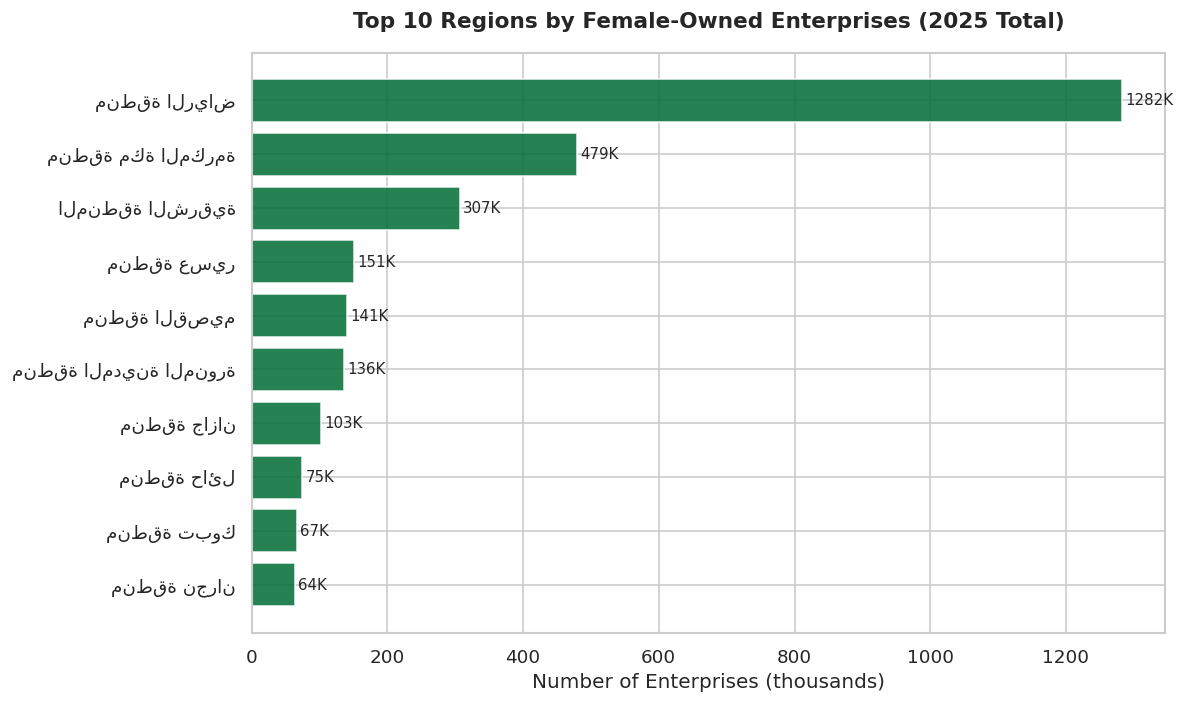

In [ ]:
# ── Chart 2: Top regions (horizontal bar) ────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# .tail(10) → last 10 (since sorted ascending, these are the highest)
top10 = top_regions.sort_values(ascending=True).tail(10)

bars = ax.barh(top10.index, top10.values / 1000, color=PALETTE[1], alpha=0.85, edgecolor='white')

# Add value labels
for bar, val in zip(bars, top10.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val/1000:.0f}K', va='center', fontsize=9)

ax.set_title('Top 10 Regions by Female-Owned Enterprises (2025 Total)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Number of Enterprises (thousands)')
plt.tight_layout()
plt.show()

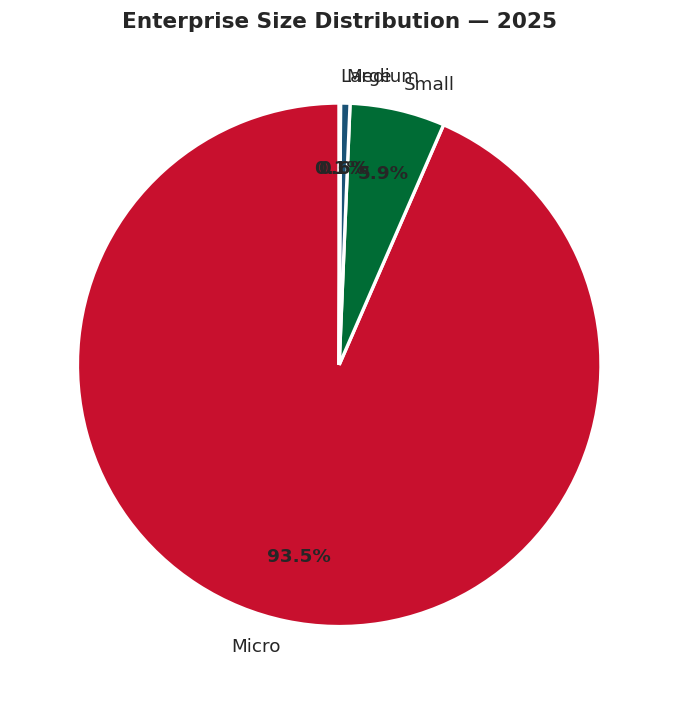

In [ ]:
# ── Chart 3: Enterprise size distribution (pie) ───────────────────
# Translate sizes to English
size_en = {
    'متناهية الصغر': 'Micro',
    'صغيرة':         'Small',
    'متوسطة':        'Medium',
    'كبيرة':         'Large',
}
size_dist_en = size_dist.copy()
size_dist_en.index = [size_en.get(s, s) for s in size_dist_en.index]

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    size_dist_en.values,
    labels=size_dist_en.index,
    autopct='%1.1f%%',          # show % with 1 decimal
    colors=PALETTE,
    startangle=90,              # rotate so largest slice is at top
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

ax.set_title('Enterprise Size Distribution — 2025', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6 — Forecast to 2030

Quarterly totals show a consistent upward trend — +13.4% growth from Q1 to Q4 2025. A linear regression is fitted on the four aggregated quarterly data points and extrapolated through 2030, yielding a projected growth rate of approximately **+29,400 enterprises per quarter**.

> ⚠️ **Limitation:** With only 4 training points, R² and RMSE measure training fit, not generalization. The forecast is a directional estimate. 95% prediction intervals are shown in the chart to communicate the range of uncertainty.

---
## Step 6 — Machine Learning: Forecast to 2030

### 🤖 Why Linear Regression?
Our quarterly data shows a **clear upward linear trend** — the count increases steadily each quarter.
Linear Regression finds the best-fit straight line: `y = mx + b`
- `y` = predicted enterprise count
- `x` = time_index (our engineered feature)
- `m` = slope (how much count increases per quarter)
- `b` = intercept

### 🔧 Sklearn Methods Used

| Method | What it does |
|---|---|
| `LinearRegression()` | Creates the model object |
| `.fit(X, y)` | **Trains** the model — finds the best `m` and `b` |
| `.predict(X)` | Uses the trained model to make predictions |
| `.coef_` | Returns the slope `m` |
| `.intercept_` | Returns the intercept `b` |
| `r2_score(y_true, y_pred)` | R² score: how well model explains variance (0–1, higher=better) |
| `mean_squared_error(...)` | MSE: average squared error |
| `np.sqrt(mse)` | RMSE: square root of MSE (same unit as count) |

In [ ]:
# ── 6a. Prepare training data ────────────────────────────────────
# X must be 2D: shape (n_samples, n_features) — that's why we use [['time_index']]
# y is 1D: shape (n_samples,)
X = quarterly[['time_index']].values   # shape: (4, 1) — 4 quarters, 1 feature
y = quarterly['count'].values          # shape: (4,)  — 4 target values

print(f'X shape: {X.shape}  →  {X.flatten()}')
print(f'y shape: {y.shape}  →  {y}')

X shape: (4, 1)  →  [8101 8102 8103 8104]
y shape: (4,)  →  [682598 709779 729269 774123]


In [ ]:
# ── 6c. Evaluate the model ────────────────────────────────────────
y_pred = model.predict(X)     # .predict() → generate predictions on training data

r2   = r2_score(y, y_pred)                        # R² score (0 to 1)
mse  = mean_squared_error(y, y_pred)              # Mean Squared Error
rmse = np.sqrt(mse)                               # Root Mean Squared Error

print('── Model Evaluation ──────────────────')
print(f'R² Score : {r2:.4f}   (1.0 = perfect, >0.9 = excellent)')
print(f'RMSE     : {rmse:,.0f}   (average error in number of enterprises)')
print()
print('⚠️  Note: metrics are computed on the same 4 training points used to fit')
print('   the model — they reflect training fit, not forecast accuracy.')

# Quick interpretation
if r2 >= 0.95:
    print('\n✅ Excellent fit — the trend is very linear and consistent.')
elif r2 >= 0.80:
    print('\n✅ Good fit — the model captures the main trend.')
else:
    print('\n⚠️  Moderate fit — consider polynomial regression or more data.')

In [ ]:
# ── 6d. Generate future predictions with 95% prediction intervals ─
future_rows = []
for yr in range(2026, 2031):          # years 2026 to 2030
    for qr in range(1, 5):            # quarters 1 to 4
        ti = yr * 4 + qr              # same formula as before
        future_rows.append({
            'year': yr,
            'quarter': qr,
            'label': f'{yr}-Q{qr}',
            'time_index': ti
        })

future_df = pd.DataFrame(future_rows)
future_df['predicted'] = model.predict(future_df[['time_index']].values)

# ── 95% Prediction Interval ───────────────────────────────────────
# PI = y_hat ± t * s * sqrt(1 + 1/n + (x - x_bar)² / Σ(xi - x_bar)²)
# With n=4 and df=n-2=2, t_crit ≈ 4.303 for 95% two-tailed
n       = len(X)
x_bar   = X.mean()
SSx     = np.sum((X.flatten() - x_bar) ** 2)
s       = np.sqrt(np.sum((y - y_pred) ** 2) / (n - 2))  # residual std error
t_crit  = stats.t.ppf(0.975, df=n - 2)                  # 95% PI, 2-tailed, df=2

x_fut   = future_df['time_index'].values
se_pred = s * np.sqrt(1 + 1/n + (x_fut - x_bar) ** 2 / SSx)

future_df['pi_lower'] = future_df['predicted'] - t_crit * se_pred
future_df['pi_upper'] = future_df['predicted'] + t_crit * se_pred

# Annual totals
yearly_pred = future_df.groupby('year')['predicted'].sum()

print('── Forecast: Annual Total Enterprises ──')
for yr, val in yearly_pred.items():
    growth = ((val / quarterly['count'].sum()) - 1) * 100
    print(f'  {yr}: {val:>12,.0f}  enterprises  ({growth:+.1f}% vs 2025 total)')

In [ ]:
# ── 6e. Forecast visualization with 95% prediction interval ──────
fig, ax = plt.subplots(figsize=(16, 7))

# Historical actual data (bars)
x_hist = list(range(len(quarterly)))
ax.bar(x_hist, quarterly['count'] / 1000,
       color=PALETTE[0], alpha=0.9, label='Actual (2025)', zorder=3)

# Trend line over historical data
ax.plot(x_hist, y_pred / 1000,
        color='#2C3E50', linewidth=2.5, linestyle='--',
        label='Trend line', zorder=4)

# Future predicted data (bars)
x_future = list(range(len(quarterly), len(quarterly) + len(future_df)))
ax.bar(x_future, future_df['predicted'] / 1000,
       color=PALETTE[2], alpha=0.7, label='Forecast (2026–2030)', zorder=3)

# 95% Prediction interval shaded band
ax.fill_between(
    x_future,
    future_df['pi_lower'] / 1000,
    future_df['pi_upper'] / 1000,
    color=PALETTE[2], alpha=0.15, label='95% Prediction Interval', zorder=2
)

# Vertical line separating actual from forecast
ax.axvline(x=len(quarterly) - 0.5, color='red', linestyle=':', linewidth=2, alpha=0.8)

# X-axis labels
all_labels = quarterly['label'].tolist() + future_df['label'].tolist()
ax.set_xticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=45, ha='right', fontsize=8)

# Annotate 2030-Q4
last_x   = len(quarterly) + len(future_df) - 1
last_val = future_df.iloc[-1]['predicted']
ax.annotate(
    f"2030-Q4\n{last_val/1000:.0f}K",
    xy=(last_x, last_val / 1000),
    xytext=(last_x - 4, last_val / 1000 + 60),
    arrowprops=dict(arrowstyle='->', color=PALETTE[2], lw=1.5),
    fontsize=11, color=PALETTE[2], fontweight='bold'
)

ax.set_title('Female-Owned Enterprises — Historical Data & Forecast to 2030 (95% PI)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Period')
ax.set_ylabel('Number of Enterprises (thousands)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7 — Key Findings

**Growth trajectory** — Female-owned enterprises grew 13.4% across 2025, from 682,598 in Q1 to 774,123 in Q4, with acceleration in the second half of the year.

**Regional concentration** — Riyadh alone accounts for **44%** of all female-owned enterprises (1.28M of 2.9M total). The top 3 regions — Riyadh, Makkah, and the Eastern Province — represent **71%** of the national total.

**Enterprise profile** — **94% are micro-sized**, reflecting a foundation of small independent businesses rather than scaled enterprises. Medium and large firms together account for under 1%.

**Sector note** — Building construction ranks first (466K), followed by unclassified activity (426K, ~15% of total). Retail trade and food services round out the top 4. The high share of unclassified activity limits sector-level conclusions.

**2030 Forecast** — Under a linear growth assumption, total female-owned enterprises are projected to reach **~5.2 million by 2030**, representing +81% growth over the 2025 baseline. This aligns directionally with Saudi Vision 2030 targets for female economic participation.

| Year | Projected Annual Total |
|---|---|
| 2026 | ~3.4 million |
| 2027 | ~3.8 million |
| 2028 | ~4.3 million |
| 2029 | ~4.8 million |
| **2030** | **~5.2 million** |

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ── Final summary printout ────────────────────────────────────────
print('=' * 55)
print('   FEMALE-OWNED ENTERPRISES — PROJECT SUMMARY')
print('=' * 55)
print(f'\n  Dataset rows (after cleaning) : {df.shape[0]:,}')
print(f'  Regions                       : {df["region"].nunique()}')
print(f'  Economic activities           : {df["activity"].nunique()}')
print(f'\n  Model  →  R² = {r2:.4f}  |  RMSE = {rmse:,.0f}')
print(f'  Slope  →  +{model.coef_[0]:,.0f} enterprises per quarter')
print()
print('  2030 Annual Forecast:')
for yr, val in yearly_pred.items():
    print(f'    {yr}  →  {val:>12,.0f} enterprises')
print()
print('  Forecast 2030-Q4 (single quarter):')
print(f'    {future_df.iloc[-1]["predicted"]:,.0f} enterprises')
print('=' * 55)

   FEMALE-OWNED ENTERPRISES — PROJECT SUMMARY

  Dataset rows (after cleaning) : 13,069
  Regions                       : 13
  Economic activities           : 89

  Model  →  R² = 0.9702  |  RMSE = 5,760
  Slope  →  +29,406 enterprises per quarter

  2030 Annual Forecast:
    2026  →     3,366,273 enterprises
    2027  →     3,836,777 enterprises
    2028  →     4,307,281 enterprises
    2029  →     4,777,785 enterprises
    2030  →     5,248,289 enterprises

  Forecast 2030-Q4 (single quarter):
    1,356,182 enterprises
